# XGBoost

XGBoost stands for **Extreme Gradient Boosting**.

It is an optimized implementation of Gradient Boosting that is widely used for supervised learning problems, especially for structured/tabular data.

XGBoost builds an ensemble of decision trees sequentially.

Each new tree attempts to correct the errors made by the previous trees.

The main ideas behind XGBoost are:

- Gradient Boosting
- Decision Trees
- Gradient-based optimization
- Regularization
- Shrinkage
- Row and column subsampling
- Efficient tree construction

XGBoost can be used for:

- Classification
- Regression
- Ranking
- Binary classification
- Multiclass classification

## 1. Why XGBoost?

A single decision tree can easily overfit the training data.

Instead of relying on one tree, ensemble methods combine multiple trees.

There are two major approaches:

- **Bagging** → build trees independently and combine them
- **Boosting** → build trees sequentially, where each tree improves the previous model

XGBoost belongs to the **boosting** family.

The basic idea is:

$$
Model = Tree_1 + Tree_2 + Tree_3 + \cdots + Tree_M
$$

Each new tree contributes a correction to the current prediction.

## 2. XGBoost vs Gradient Boosting

XGBoost is based on the same fundamental idea as Gradient Boosting, but introduces several improvements.

### Traditional Gradient Boosting

The model is built sequentially:

$$
F_m(x) = F_{m-1}(x) + \eta h_m(x)
$$

where:

- $F_m(x)$ = model after adding tree $m$
- $F_{m-1}(x)$ = previous model
- $h_m(x)$ = new decision tree
- $\eta$ = learning rate

### XGBoost adds

- Explicit regularization
- Second-order optimization
- Efficient tree construction
- Row subsampling
- Column subsampling
- Missing-value handling
- Parallel computation
- Shrinkage
- Tree complexity control

Therefore, XGBoost is generally more flexible and optimized than basic Gradient Boosting.

## 3. Core Intuition

Suppose we want to predict house prices.

The first tree makes an initial prediction.

The second tree looks at where the first tree made mistakes and learns a correction.

The third tree learns another correction.

This continues for many iterations.

Conceptually:

$$
Prediction =
Initial\ Prediction
+
Correction_1
+
Correction_2
+
\cdots
+
Correction_M
$$

Therefore, XGBoost gradually improves the model by adding weak learners.

## 4. Mathematical Formulation

XGBoost represents the final model as a sum of decision trees.

$$
\hat{y}_i =
\sum_{k=1}^{K} f_k(x_i)
$$

where:

- $K$ = number of trees
- $f_k$ = the $k$-th decision tree
- $x_i$ = feature vector of sample $i$
- $\hat{y}_i$ = prediction for sample $i$

The objective function is:

$$
Obj =
\sum_{i=1}^{n}
L(y_i,\hat{y}_i)
+
\sum_{k=1}^{K}
\Omega(f_k)
$$

The first term measures prediction error.

The second term controls model complexity.

This is one of the most important ideas in XGBoost:

$$
Objective =
Loss +
Regularization
$$

## 5. Regularization

XGBoost explicitly penalizes complex trees.

The regularization term can be written as:

$$
\Omega(f)
=
\gamma T
+
\frac{1}{2}\lambda
\sum_{j=1}^{T}
w_j^2
+
\alpha
\sum_{j=1}^{T}
|w_j|
$$

where:

- $T$ = number of leaves
- $w_j$ = score of leaf $j$
- $\gamma$ = penalty for adding a leaf
- $\lambda$ = L2 regularization
- $\alpha$ = L1 regularization

Therefore:

- `gamma` controls tree complexity
- `reg_lambda` controls L2 regularization
- `reg_alpha` controls L1 regularization

Regularization helps reduce overfitting.

## 6. First-Order and Second-Order Information

Traditional Gradient Boosting primarily uses the gradient.

XGBoost uses both:

- First-order gradient
- Second-order gradient (Hessian)

For each training example:

$$
g_i =
\frac{\partial L(y_i,\hat{y}_i)}
{\partial \hat{y}_i}
$$

and

$$
h_i =
\frac{\partial^2 L(y_i,\hat{y}_i)}
{\partial \hat{y}_i^2}
$$

The objective can then be approximated using a second-order Taylor expansion.

This gives XGBoost more information about the shape of the loss function and helps it optimize tree construction efficiently.

## 7. How XGBoost Builds a Tree

At every boosting iteration:

1. Calculate current predictions.
2. Calculate gradients.
3. Calculate Hessians.
4. Search for useful tree splits.
5. Evaluate the quality of each split.
6. Add the best tree.
7. Update the predictions.
8. Repeat.

The overall process is:

$$
Initial\ Model
\rightarrow
Gradients/Hessians
\rightarrow
Best\ Tree
\rightarrow
Updated\ Model
\rightarrow
Repeat
$$

## 8. Split Gain

XGBoost evaluates whether splitting a node improves the objective.

A simplified form of the split gain is:

$$
Gain =
\frac{1}{2}
\left[
\frac{G_L^2}{H_L+\lambda}
+
\frac{G_R^2}{H_R+\lambda}
-
\frac{G^2}{H+\lambda}
\right]
-
\gamma
$$

where:

- $G_L$ = sum of gradients in the left node
- $G_R$ = sum of gradients in the right node
- $G$ = total gradient
- $H_L$ = sum of Hessians in the left node
- $H_R$ = sum of Hessians in the right node
- $H$ = total Hessian
- $\lambda$ = L2 regularization
- $\gamma$ = complexity penalty

A split is useful when it provides sufficient improvement in the objective.

This is one reason XGBoost can control tree complexity very effectively.

## 9. Learning Rate

The learning rate controls how strongly each new tree affects the final model.

It is commonly represented as:

$$
\eta
$$

The update is approximately:

$$
F_m(x)
=
F_{m-1}(x)
+
\eta h_m(x)
$$

A smaller learning rate usually requires more trees.

For example:

- Small `learning_rate` → slower learning, usually more trees
- Large `learning_rate` → faster learning, usually fewer trees

Typical values might be:

```text
0.01
0.05
0.1
0.2


A common strategy is:

$$ Small\ Learning\ Rate + Large\ Number\ of\ Trees $$

This can produce a strong model while reducing the risk of overfitting.


---


## 10. Important XGBoost Hyperparameters

### Number of trees

`n_estimators`

Controls the number of boosting rounds.

More trees can improve performance but may increase training time and overfitting.

### Learning rate

`learning_rate`

Controls the contribution of each tree.

### Maximum tree depth

`max_depth`

Controls how deep each tree can grow.

Larger values allow more complex models.

### Minimum child weight

`min_child_weight`

Controls the minimum amount of Hessian weight required in a child node.

Larger values make the model more conservative.

### Gamma

`gamma`

Minimum loss reduction required to make a split.

Higher values produce more conservative trees.

### Subsample

`subsample`

Fraction of training rows used for each tree.

### Column sampling

`colsample_bytree`

Fraction of features considered for each tree.

### L1 regularization

`reg_alpha`

Controls L1 regularization.

### L2 regularization

`reg_lambda`

Controls L2 regularization.

## 11. Important Hyperparameters at a Glance

| Parameter | Purpose |
|---|---|
| `n_estimators` | Number of trees |
| `learning_rate` | Contribution of each tree |
| `max_depth` | Maximum tree depth |
| `min_child_weight` | Minimum child-node weight |
| `gamma` | Minimum split improvement |
| `subsample` | Row sampling |
| `colsample_bytree` | Feature sampling |
| `reg_alpha` | L1 regularization |
| `reg_lambda` | L2 regularization |
| `objective` | Learning objective |
| `eval_metric` | Evaluation metric |

## Practical Implementation

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score
)

from xgboost import XGBClassifier

## 12. Load Dataset

We will use the Breast Cancer dataset from Scikit-learn.

This is a binary classification problem.

The target represents:

- `0` → malignant
- `1` → benign

We will train an XGBoost classifier to predict the target.

In [2]:
data = load_breast_cancer()

X = pd.DataFrame(
    data.data,
    columns=data.feature_names
)

y = pd.Series(
    data.target,
    name="target"
)

X.shape, y.shape

((569, 30), (569,))

In [3]:
X.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [4]:
y.value_counts()

target
1    357
0    212
Name: count, dtype: int64

## 13. Train-Test Split

We divide the dataset into:

- Training set
- Testing set

The model learns from the training set.

The test set is used to evaluate generalization.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train.shape, X_test.shape

((455, 30), (114, 30))

## 14. Train the XGBoost Model

We start with a relatively conservative configuration.

```text
n_estimators = 200
learning_rate = 0.05
max_depth = 4
subsample = 0.8
colsample_bytree = 0.8

The combination of a smaller learning rate and multiple trees allows the model to learn gradually.

In [6]:
model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42
)

model.fit(
    X_train,
    y_train
)

,"objective objective: str | xgboost.objective.Objective | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBR

## 15. Make Predictions

In [7]:
y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:, 1]

y_pred[:10]

array([0, 1, 0, 0, 0, 1, 1, 0, 0, 0])

## 16. Accuracy

In [8]:
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.9561


## 17. Classification Report

In [9]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.93      0.94        42
           1       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



## 18. Confusion Matrix

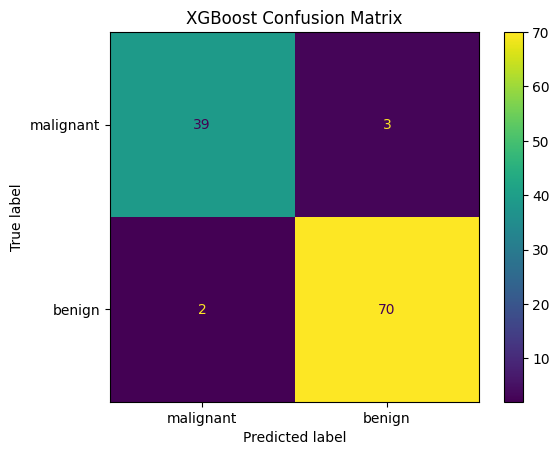

In [10]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=data.target_names
)

disp.plot()

plt.title("XGBoost Confusion Matrix")
plt.show()

## 19. ROC-AUC

ROC-AUC measures how well the model separates the two classes across different classification thresholds.

For binary classification:

$$
AUC = Area\ Under\ the\ ROC\ Curve
$$

A value closer to 1 generally indicates better class separation.

In [11]:
roc_auc = roc_auc_score(
    y_test,
    y_prob
)

print(f"ROC-AUC: {roc_auc:.4f}")

ROC-AUC: 0.9947


## 20. Feature Importance

XGBoost can provide feature importance scores.

These scores help identify which features contributed most to the model.

However, feature importance should not automatically be interpreted as causal importance.

In [12]:
importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

importance.head(10)

worst perimeter         0.303943
worst radius            0.179639
mean concave points     0.106608
worst concave points    0.070053
worst concavity         0.035723
mean area               0.025648
worst area              0.024594
worst compactness       0.022336
mean texture            0.018009
area error              0.016385
dtype: float32

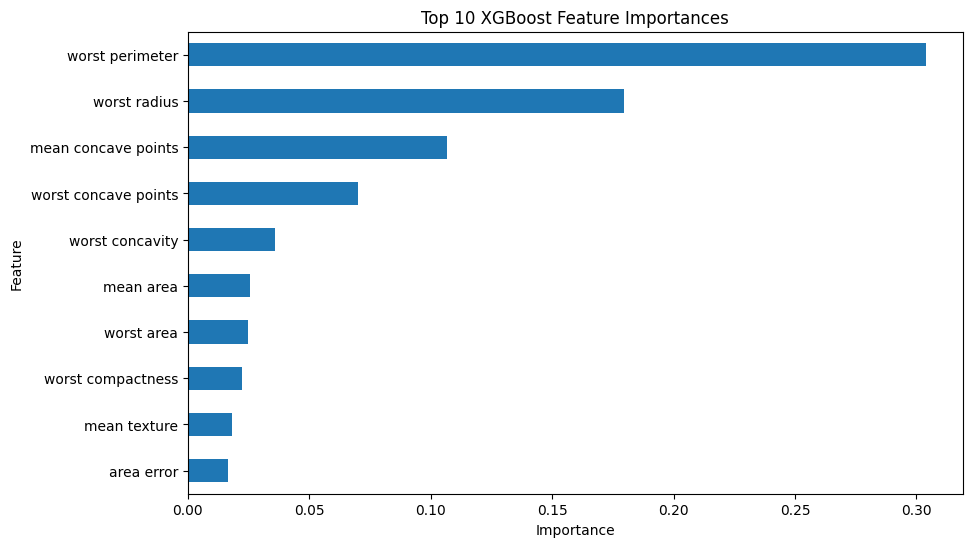

In [13]:
plt.figure(figsize=(10, 6))

importance.head(10).sort_values().plot(
    kind="barh"
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 XGBoost Feature Importances")

plt.show()

## 21. Training Performance Across Boosting Rounds

XGBoost builds trees sequentially.

We can inspect evaluation metrics across boosting rounds.

This helps us understand how the model learns over time.

In [14]:
model_with_eval = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42
)

model_with_eval.fit(
    X_train,
    y_train,
    eval_set=[
        (X_train, y_train),
        (X_test, y_test)
    ],
    verbose=False
)

,"objective objective: str | xgboost.objective.Objective | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBR

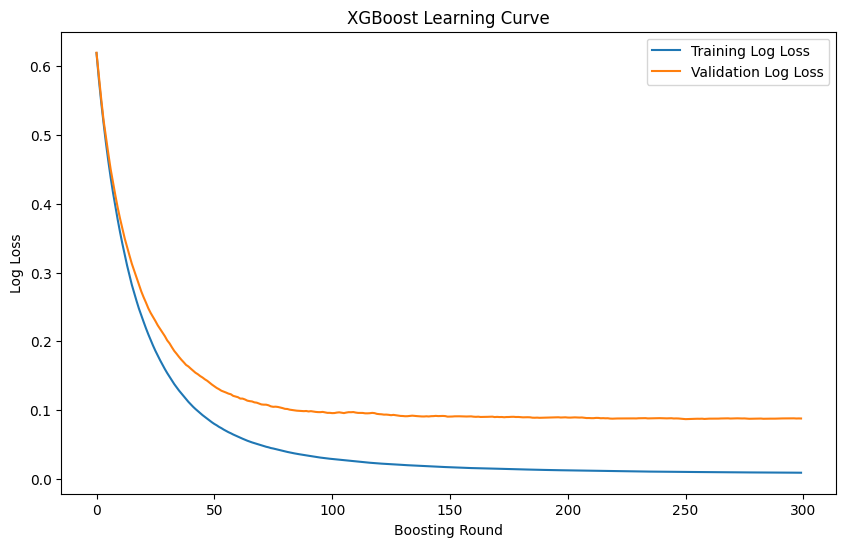

In [15]:
results = model_with_eval.evals_result()

train_logloss = results["validation_0"]["logloss"]
test_logloss = results["validation_1"]["logloss"]

plt.figure(figsize=(10, 6))

plt.plot(
    train_logloss,
    label="Training Log Loss"
)

plt.plot(
    test_logloss,
    label="Validation Log Loss"
)

plt.xlabel("Boosting Round")
plt.ylabel("Log Loss")
plt.title("XGBoost Learning Curve")

plt.legend()

plt.show()

## 22. Interpreting the Learning Curve

Ideally, both training and validation loss should decrease.

A possible pattern is:

### Healthy training

Training loss decreases.

Validation loss also decreases.

### Overfitting

Training loss continues decreasing while validation loss starts increasing.

This indicates that the model is beginning to memorize the training data.

Therefore, the number of boosting rounds should not always be increased indefinitely.

## 23. Early Stopping

Early stopping prevents unnecessary boosting rounds.

The idea is:

- Train many trees.
- Monitor validation performance.
- Stop when performance stops improving.

Conceptually:

$$
Stop\ Training
\quad \text{if validation performance does not improve}
$$

Early stopping can help reduce overfitting and unnecessary computation.

The exact API for early stopping can vary across XGBoost versions, so it is useful to check the installed XGBoost version before using version-specific training arguments.

In [16]:
import xgboost as xgb

print("XGBoost version:", xgb.__version__)

XGBoost version: 3.4.1


## 24. Effect of Tree Depth

`max_depth` controls the maximum depth of each tree.

Small depth:

- Simpler trees
- Lower variance
- May underfit

Large depth:

- More complex trees
- Can capture complicated patterns
- Higher risk of overfitting

Therefore:

$$
Increasing\ max\_depth
\Rightarrow
Model\ Complexity \uparrow
$$

In [17]:
depths = [2, 3, 4, 6, 8]

depth_results = []

for depth in depths:
    temp_model = XGBClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=depth,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42
    )

    temp_model.fit(
        X_train,
        y_train
    )

    train_accuracy = temp_model.score(
        X_train,
        y_train
    )

    test_accuracy = temp_model.score(
        X_test,
        y_test
    )

    depth_results.append(
        [depth, train_accuracy, test_accuracy]
    )

depth_results = pd.DataFrame(
    depth_results,
    columns=[
        "max_depth",
        "train_accuracy",
        "test_accuracy"
    ]
)

depth_results

,max_depth,train_accuracy,test_accuracy
0,2,0.997802,0.95614
1,3,1.000000,0.95614
2,4,1.000000,0.95614
3,6,1.000000,0.95614
4,8,1.000000,0.95614


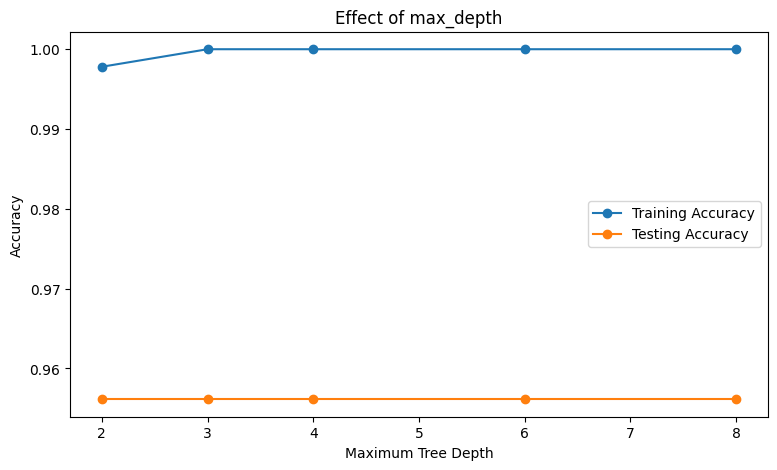

In [18]:
plt.figure(figsize=(9, 5))

plt.plot(
    depth_results["max_depth"],
    depth_results["train_accuracy"],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    depth_results["max_depth"],
    depth_results["test_accuracy"],
    marker="o",
    label="Testing Accuracy"
)

plt.xlabel("Maximum Tree Depth")
plt.ylabel("Accuracy")
plt.title("Effect of max_depth")

plt.legend()

plt.show()

## 25. XGBoost vs Random Forest

Both methods use multiple decision trees, but they work differently.

### Random Forest

Random Forest uses bagging.

Trees are trained independently.

$$
Tree_1,\ Tree_2,\ Tree_3,\ldots,Tree_M
$$

The predictions are then combined.

### XGBoost

XGBoost uses boosting.

Trees are trained sequentially.

$$
Tree_1
\rightarrow
Tree_2
\rightarrow
Tree_3
\rightarrow
\cdots
$$

Each new tree attempts to improve the current model.

### Main difference

Random Forest:

$$
Independent\ Trees
$$

XGBoost:

$$
Sequentially\ Correcting\ Trees
$$

## 26. XGBoost vs Random Forest Comparison

| Property | Random Forest | XGBoost |
|---|---|---|
| Ensemble type | Bagging | Boosting |
| Trees | Independent | Sequential |
| Main goal | Reduce variance | Reduce bias and improve prediction |
| Training | Highly parallel | Sequential across boosting rounds |
| Overfitting | Relatively resistant | Can overfit without tuning |
| Regularization | Less explicit | Strong explicit regularization |
| Hyperparameters | Easier | More extensive |
| Tabular data | Excellent | Excellent |
| Interpretability | Moderate | Moderate |
| Training complexity | Lower | Higher |

## 27. Controlling Model Complexity

Several parameters can control overfitting.

### `max_depth`

Controls tree depth.

Higher values:

$$
Complexity \uparrow
$$

### `min_child_weight`

Higher values make splitting more difficult.

### `gamma`

Higher values require greater improvement before making a split.

### `reg_alpha`

Adds L1 regularization.

### `reg_lambda`

Adds L2 regularization.

### `subsample`

Uses only a fraction of rows for each tree.

### `colsample_bytree`

Uses only a fraction of features for each tree.

## 28. Advantages of XGBoost

### 1. Excellent performance

XGBoost often performs extremely well on structured/tabular datasets.

### 2. Regularization

It provides explicit L1 and L2 regularization.

### 3. Handles nonlinear relationships

Decision trees naturally capture nonlinear relationships.

### 4. Handles feature interactions

Trees can automatically learn interactions between features.

### 5. Missing values

XGBoost can learn how to handle missing values during tree construction.

### 6. Flexible objectives

It supports different learning objectives and evaluation metrics.

### 7. Feature subsampling

Rows and features can be sampled to reduce overfitting.

### 8. Efficient implementation

XGBoost is optimized for performance and large datasets.

## 29. Disadvantages of XGBoost

### 1. Hyperparameter tuning can be difficult

There are many important parameters.

### 2. Can overfit

Deep trees, too many boosting rounds, or an overly aggressive learning rate can cause overfitting.

### 3. Less interpretable than a single tree

The final model may contain hundreds of trees.

### 4. Training can be computationally expensive

Large datasets and many boosting rounds can require significant resources.

### 5. Sensitive to parameter choices

Poor parameter choices can significantly reduce performance.

### 6. Not always necessary

For small or simple datasets, simpler models may perform equally well while being easier to understand.

## 30. When Should You Use XGBoost?

XGBoost is particularly useful when:

- Your data is structured/tabular.
- Relationships are nonlinear.
- Feature interactions are important.
- Prediction performance is important.
- You have enough data for ensemble learning.
- You are willing to tune hyperparameters.

Common applications include:

- Fraud detection
- Credit risk
- Customer churn
- Ranking
- Recommendation systems
- Classification
- Regression
- Forecasting with engineered tabular features

## 31. When Should You Avoid XGBoost?

XGBoost may not be the best first choice when:

- You need a highly interpretable model.
- The dataset is extremely small.
- A simple linear relationship already explains the problem.
- You are working directly with raw images.
- You are working directly with raw audio.
- You are working directly with raw text.

For unstructured data such as images, text, and audio, deep learning models may be more appropriate.

For simple tabular problems, start with simpler baselines before adding complexity.

## 32. Practical XGBoost Workflow

A good workflow is:

### Step 1 — Understand the data

Check:

- Missing values
- Feature types
- Target distribution
- Outliers
- Class imbalance

### Step 2 — Create a baseline

Try a simple model first.

### Step 3 — Split the data

Use training and validation data appropriately.

### Step 4 — Start with conservative XGBoost parameters

For example:

```text
moderate max_depth
small learning_rate
reasonable n_estimators
subsample < 1
colsample_bytree < 1

Step 5 — Tune important hyperparameters

Focus on:

learning_rate
n_estimators
max_depth
min_child_weight
gamma
subsample
colsample_bytree
reg_alpha
reg_lambda
Step 6 — Use cross-validation

Evaluate whether improvements generalize.

Step 7 — Check for overfitting

Compare training and validation performance.

Step 8 — Evaluate on the final test set

Only use the test set for final unbiased evaluation.


---

# 33. Summary

XGBoost is a powerful gradient boosting algorithm based on decision trees.

The model is built sequentially:

$$
F_M(x)
=
\sum_{m=1}^{M}
\eta h_m(x)
$$

Each new tree attempts to improve the existing model.

The XGBoost objective combines:

$$
Objective =
Loss +
Regularization
$$

Important concepts include:

- Gradient Boosting
- Decision Trees
- Gradients
- Hessians
- Split Gain
- Learning Rate
- Regularization
- Shrinkage
- Row Subsampling
- Feature Subsampling
- Tree Depth
- Early Stopping

Important hyperparameters include:

- `n_estimators`
- `learning_rate`
- `max_depth`
- `min_child_weight`
- `gamma`
- `subsample`
- `colsample_bytree`
- `reg_alpha`
- `reg_lambda`

The most important practical lesson is:

$$
Good\ XGBoost
\neq
Maximum\ Number\ of\ Trees
$$

Instead:

$$
Good\ XGBoost
=
Appropriate\ Complexity
+
Regularization
+
Validation
+
Careful\ Tuning
$$